**DYNAMIC SUPPLY CHAIN DEMAND FORECASTING USING MACHINE LEARNING**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
import joblib

In [2]:
sales = pd.read_csv("sales.csv",low_memory=False)
store = pd.read_csv("store.csv")
print("Sales Shape :", sales.shape)
print("Store Shape :", store.shape)

Sales Shape : (1017209, 9)
Store Shape : (1115, 10)


In [3]:
df = pd.merge(sales,store, on='Store',how='left')
print("Merged Shape :", df.shape)

Merged Shape : (1017209, 18)


In [4]:
print(df.head())
print("*"*55)
print(df.info())
print("*"*55)
print(df.describe())
print("*"*55)
print(df.isnull().sum().sort_values(ascending=False))

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                   

In [5]:
print("Duplicate Rows:",df.duplicated().sum())
df.dtypes

Duplicate Rows: 0


Store                          int64
DayOfWeek                      int64
Date                          object
Sales                          int64
Customers                      int64
Open                           int64
Promo                          int64
StateHoliday                  object
SchoolHoliday                  int64
StoreType                     object
Assortment                    object
CompetitionDistance          float64
CompetitionOpenSinceMonth    float64
CompetitionOpenSinceYear     float64
Promo2                         int64
Promo2SinceWeek              float64
Promo2SinceYear              float64
PromoInterval                 object
dtype: object

**FEATURE ENGINEERING**

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = (df['DayOfWeek'] >= 6).astype(int)

**Handling Missing Values**

In [8]:
# If there is no competition opening information, fill with 0 (Not Applicable)
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear'] = df['CompetitionOpenSinceYear'].fillna(0)

# If competition distance is nan, assume there is no nearby competitor
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(100000)

# If Promo2 is not available, fill with 0 (Not Applicable)
df['Promo2SinceWeek'] = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear'] = df['Promo2SinceYear'].fillna(0)

# If PromoInterval is missing, mark it as 'None'
df['PromoInterval'] = df['PromoInterval'].fillna('None')

# Keep only days when the store was open and sales were greater than zero
df = df[(df['Open'] == 1) & (df['Sales'] > 0)]

df.reset_index(drop=True, inplace=True)
print("Dataset Shape:",df.shape)
print("\nMissing Values:\n")
print(df.isnull().sum())

Dataset Shape: (844338, 23)

Missing Values:

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
Year                         0
Month                        0
Day                          0
WeekOfYear                   0
IsWeekend                    0
dtype: int64


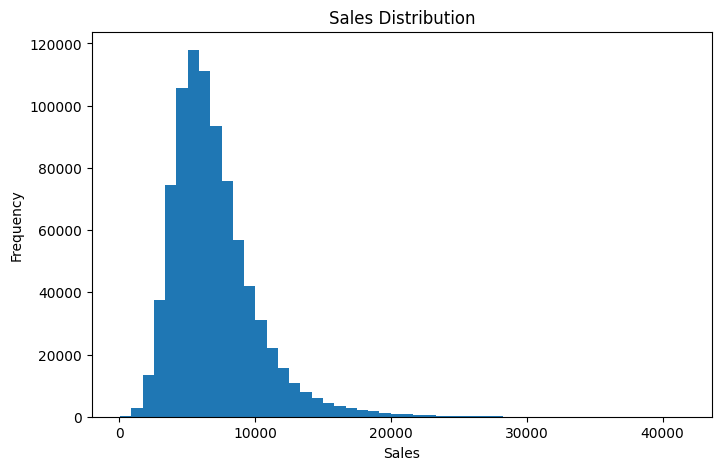

In [9]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=50)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

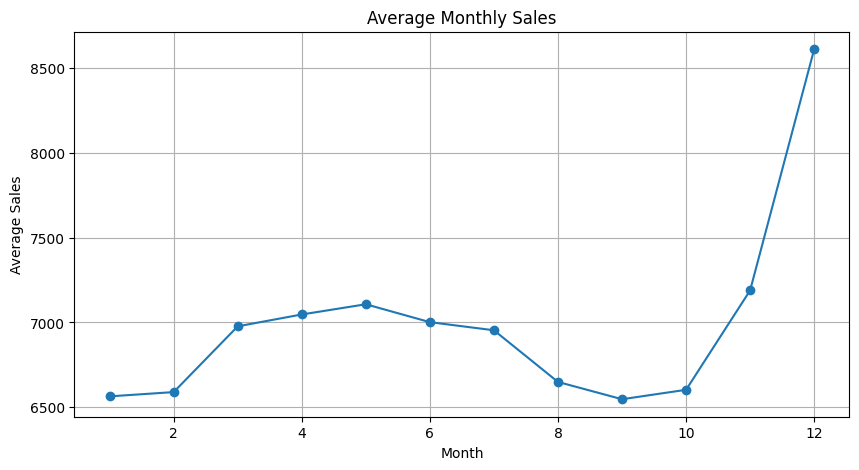

In [10]:
monthly_sales = df.groupby('Month')['Sales'].mean().reset_index()
plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o')
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.grid(True)
plt.show()

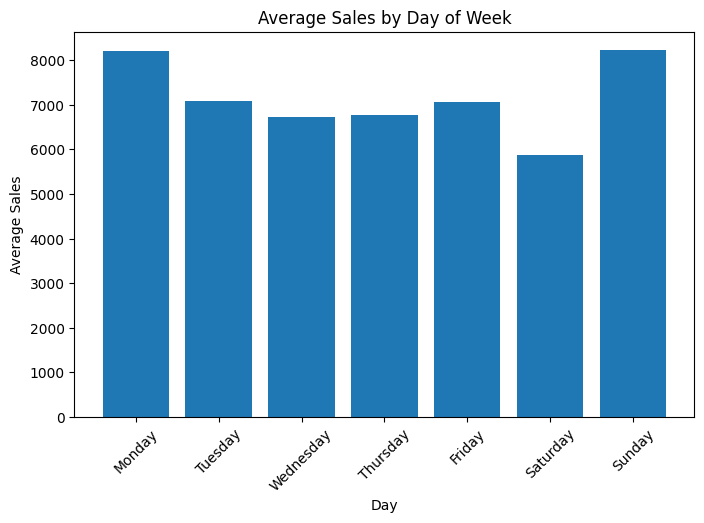

In [11]:
day_sales = df.groupby('DayOfWeek')['Sales'].mean().reset_index()
day_map = {1: 'Monday',2: 'Tuesday',3: 'Wednesday',4: 'Thursday',5: 'Friday',6: 'Saturday',7: 'Sunday'}
day_sales['DayName'] = day_sales['DayOfWeek'].map(day_map)
plt.figure(figsize=(8,5))
plt.bar(day_sales['DayName'], day_sales['Sales'])
plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")
plt.xticks(rotation=45)
plt.show()

C:\Users\fayis\AppData\Local\Temp\ipykernel_24468\1325233770.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='StoreType', y='Sales',data=plot_df,order=['Type A (Standard)', 'Type B (Flagship)', 'Type C (Medium)', 'Type D (Extended)'],palette='Set2')


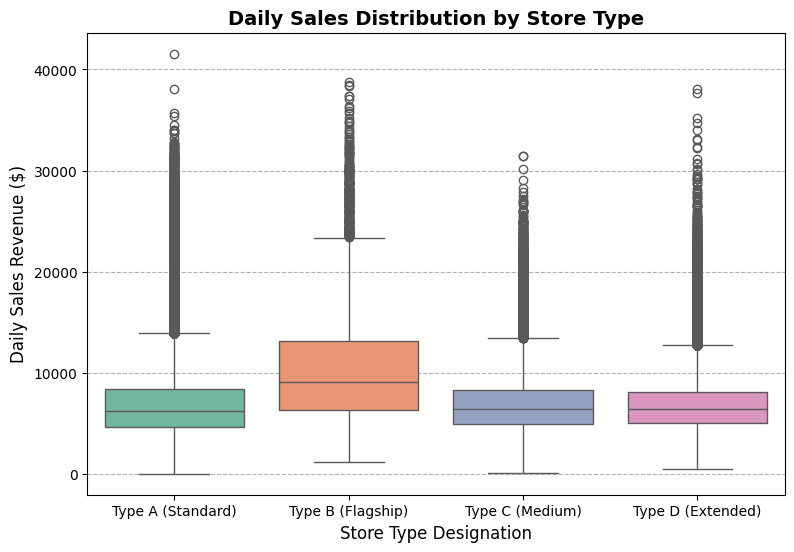

In [13]:
plot_df = df.copy()
type_labels = {'a': 'Type A (Standard)', 'b': 'Type B (Flagship)', 'c': 'Type C (Medium)', 'd': 'Type D (Extended)'}
plot_df['StoreType'] = plot_df['StoreType'].map(type_labels)

plt.figure(figsize=(9, 6))
sns.boxplot(x='StoreType', y='Sales',data=plot_df,order=['Type A (Standard)', 'Type B (Flagship)', 'Type C (Medium)', 'Type D (Extended)'],palette='Set2')
plt.title("Daily Sales Distribution by Store Type", fontsize=14, fontweight='bold')
plt.xlabel("Store Type Designation", fontsize=12)
plt.ylabel("Daily Sales Revenue ($)", fontsize=12)
plt.grid(axis='y', linestyle='--')
plt.show()

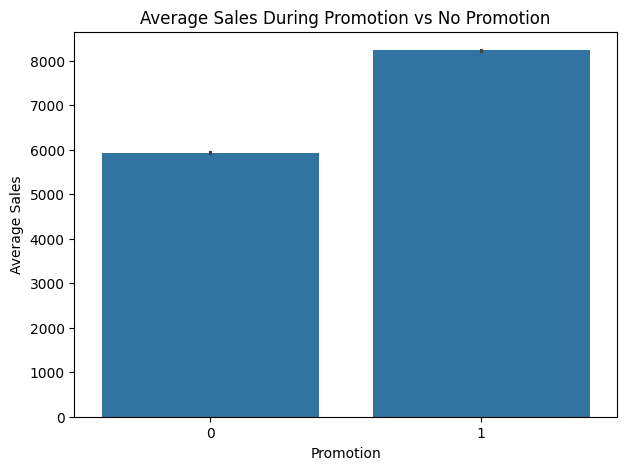

In [12]:
plt.figure(figsize=(7,5))
sns.barplot(x='Promo', y='Sales', data=df)
plt.title("Average Sales During Promotion vs No Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")
plt.show()

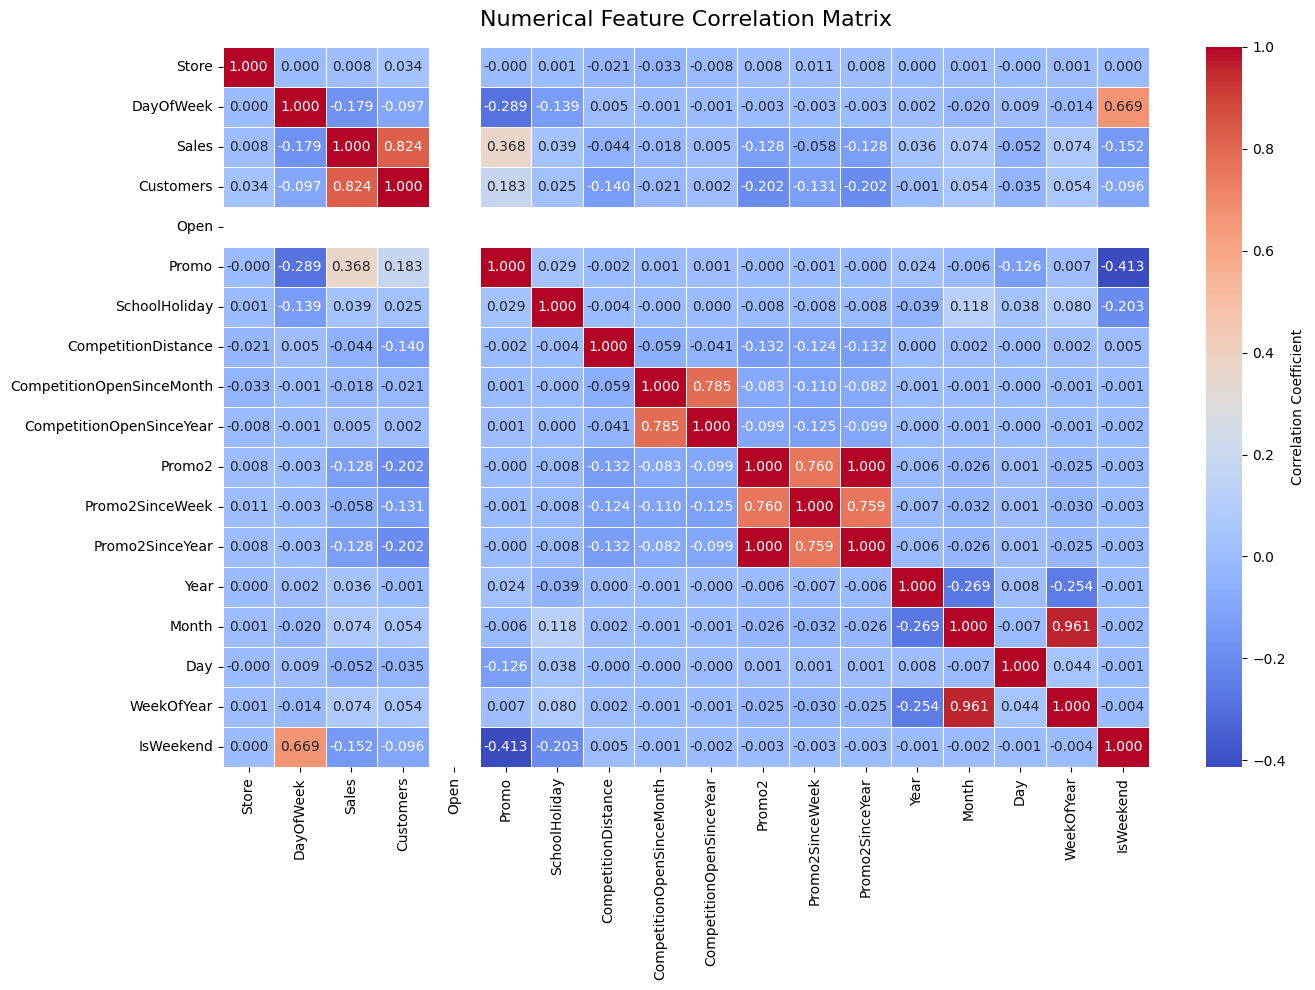

In [14]:
plt.figure(figsize=(14, 10))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.3f',linewidths=0.5)
plt.title("Numerical Feature Correlation Matrix",fontsize=16, pad=15)
plt.tight_layout()
plt.show()

In [15]:
df.drop('Date', axis=1, inplace=True)

In [16]:
df.drop('Customers', axis=1, inplace=True)

In [17]:
df.drop('Open', axis=1, inplace=True)

In [18]:
X = df.drop('Sales', axis=1)
y = df['Sales']

In [19]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

print("Categorical Columns:", len(cat_cols))
print(cat_cols)
print("\nNumerical Columns:", len(num_cols))
print(num_cols)

Categorical Columns: 4
Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object')

Numerical Columns: 15
Index(['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2',
       'Promo2SinceWeek', 'Promo2SinceYear', 'Year', 'Month', 'Day',
       'WeekOfYear', 'IsWeekend'],
      dtype='object')


In [20]:
preprocessor = ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],remainder='passthrough')

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(675470, 19)
(168868, 19)


In [22]:
lr_model = Pipeline([('preprocessor', preprocessor),('regressor', LinearRegression())])
lr_model.fit(X_train, y_train)

C:\Users\fayis\anaconda3\envs\ml_env\lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [23]:
y_pred_lr = lr_model.predict(X_test)

In [24]:
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("-------------------")
print("MAE :", round(lr_mae,2))
print("MSE :", round(lr_mse,2))
print("RMSE:", round(lr_rmse,2))
print("R² Score:", round(lr_r2,4))

Linear Regression
-------------------
MAE : 2003.61
MSE : 7506688.98
RMSE: 2739.83
R² Score: 0.2221


In [25]:
dt_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(
        random_state=42,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5))])

In [26]:
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [27]:
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, y_pred_dt)

print("Decision Tree Regressor")
print("-" * 35)
print("MAE :", round(dt_mae, 2))
print("MSE :", round(dt_mse, 2))
print("RMSE:", round(dt_rmse, 2))
print("R² Score:", round(dt_r2, 4))

Decision Tree Regressor
-----------------------------------
MAE : 930.27
MSE : 1978946.0
RMSE: 1406.75
R² Score: 0.7949


In [28]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42))])

rf_model.fit(X_train, y_train)

C:\Users\fayis\anaconda3\envs\ml_env\lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object'))])),
                ('regressor',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=5,
                                       min_samples_split=10, n_estimators=200,
                                       n_jobs=-1, random_state=42))])

In [29]:
y_pred_rf = rf_model.predict(X_test)

In [30]:
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("-" * 35)
print("MAE :", round(rf_mae, 2))
print("MSE :", round(rf_mse, 2))
print("RMSE:", round(rf_rmse, 2))
print("R² Score:", round(rf_r2, 4))

Random Forest Regressor
-----------------------------------
MAE : 795.81
MSE : 1422166.77
RMSE: 1192.55
R² Score: 0.8526


In [31]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42))])

xgb_model.fit(X_train, y_train)

C:\Users\fayis\anaconda3\envs\ml_env\lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['StateHoliday', 'StoreType', 'Assortment', 'PromoInterval'], dtype='object'))])),
                ('regressor',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=8, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [32]:
y_pred_xgb = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Regressor")
print("-" * 35)
print("MAE :", round(xgb_mae, 2))
print("MSE :", round(xgb_mse, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R² Score:", round(xgb_r2, 4))

XGBoost Regressor
-----------------------------------
MAE : 755.09
MSE : 1126738.63
RMSE: 1061.48
R² Score: 0.8832


**Feature Importance**

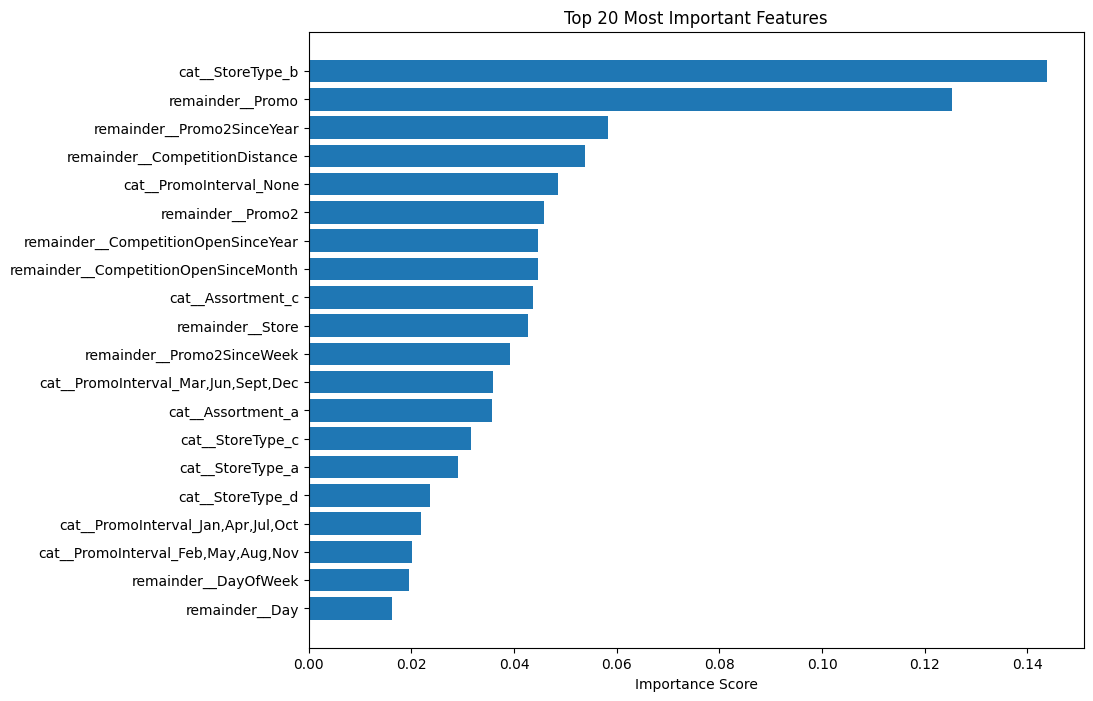

,Feature,Importance
5,cat__StoreType_b,0.143798
17,remainder__Promo,0.125384
24,remainder__Promo2SinceYear,0.058368
19,remainder__CompetitionDistance,0.053834
14,cat__PromoInterval_None,0.048589
22,remainder__Promo2,0.045851
21,remainder__CompetitionOpenSinceYear,0.044747
20,remainder__CompetitionOpenSinceMonth,0.044637
10,cat__Assortment_c,0.043641
15,remainder__Store,0.042778


In [33]:
feature_names = xgb_model.named_steps['preprocessor'].get_feature_names_out()
importance = xgb_model.named_steps['regressor'].feature_importances_
feature_importance = pd.DataFrame({'Feature': feature_names,'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance',ascending=False)
top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))
plt.barh(top20['Feature'], top20['Importance'])
plt.title("Top 20 Most Important Features")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()
feature_importance.head(20)

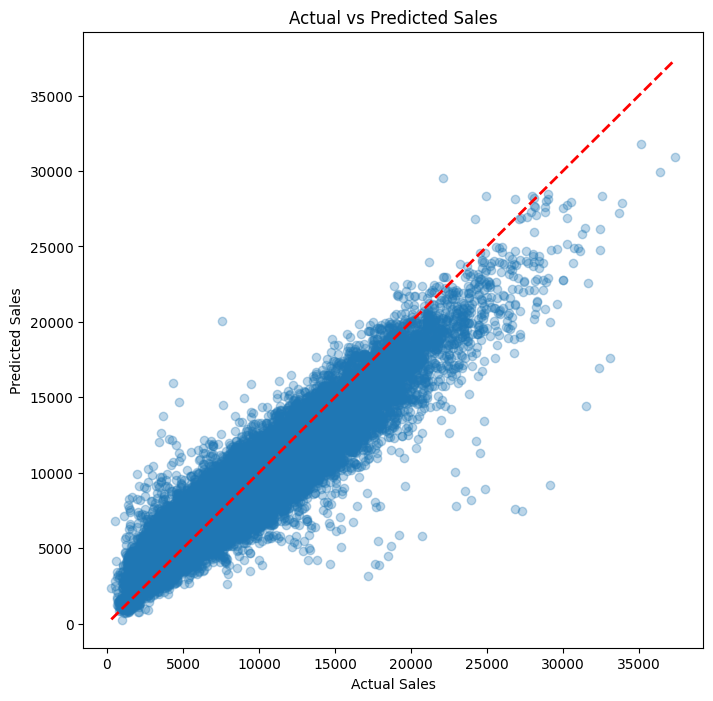

In [34]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred_xgb, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--',linewidth=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [35]:
comparison = pd.DataFrame({'Model': ['Linear Regression','Decision Tree','Random Forest','XGBoost'],
    'MAE': [lr_mae,dt_mae,rf_mae,xgb_mae],
    'RMSE': [lr_rmse,dt_rmse,rf_rmse,xgb_rmse],
    'R2 Score': [lr_r2,dt_r2,rf_r2,xgb_r2]})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2003.612915,2739.833750,0.222070
1,Decision Tree,930.270707,1406.750155,0.794919
2,Random Forest,795.812828,1192.546339,0.852619
3,XGBoost,755.094477,1061.479452,0.883234


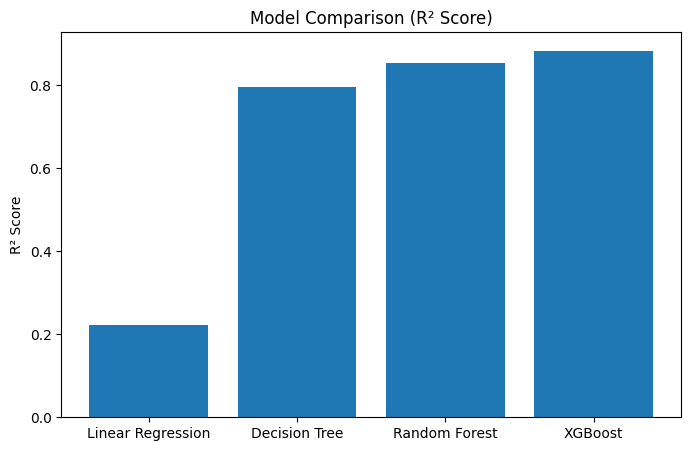

In [36]:
plt.figure(figsize=(8,5))
plt.bar(comparison['Model'], comparison['R2 Score'])
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()

In [37]:
joblib.dump(xgb_model, "xgboost_sales_model.pkl")
print("Model Saved Successfully!")

Model Saved Successfully!


In [38]:
test_df = pd.read_csv("test.csv")
store_df = pd.read_csv("store.csv")
df = pd.merge(test_df, store_df, on="Store", how="left")

print("Engineering date features")
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["IsWeekend"] = df["Date"].dt.weekday.apply(lambda x: 1 if x >= 5 else 0)

# We assume the store is open (1) if it's missing
df["Open"] = df["Open"].fillna(1)

feature_columns =["Store", "DayOfWeek", "Promo", "Open", "StateHoliday", "SchoolHoliday","StoreType", "Assortment", "CompetitionDistance", "CompetitionOpenSinceMonth","CompetitionOpenSinceYear",
                  "Promo2", "Promo2SinceWeek", "Promo2SinceYear","PromoInterval", "Year", "Month", "Day", "WeekOfYear", "IsWeekend"]
X_test = df[feature_columns]

model = joblib.load("xgboost_sales_model.pkl")
df["Predicted_Sales"] = model.predict(X_test)

# Apply business logic: Force sales to 0 on days the store is structurally closed
df.loc[df["Open"] == 0, "Predicted_Sales"] = 0
df["Predicted_Sales"] = df["Predicted_Sales"].clip(lower=0)

print("Exporting final submission predictions")
# 7. Create a clean submission dataframe containing only ID and the Forecast
submission = df[["Id", "Predicted_Sales"]]
submission.to_csv("test_predictions.csv", index=False)
print("Success!forecasts are saved to 'test_predictions.csv'.")

Engineering date features
Exporting final submission predictions
Success!forecasts are saved to 'test_predictions.csv'.


In [39]:
preds_preview = pd.read_csv("test_predictions.csv")
print(preds_preview.head(10))

   Id  Predicted_Sales
0   1        5590.7920
1   2        7392.5190
2   3       10035.4410
3   4        5397.8794
4   5        7967.2370
5   6        5662.4937
6   7        7946.5410
7   8        7453.9375
8   9        5263.6320
9  10        5670.4020
